# Particle Filter Testing

Tests across three state-space models:
1. `SimpleLinearGaussianSSM` — single filter run, MC RMSE distribution, noise sensitivity, resampling method comparison
2. `LinearTSSM` — correct vs misspecified (Gaussian) filter on t-distributed data
3. `LinearARMASSM` — filter on ARMA(1,3) latent process

In [1]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

In [2]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import matplotlib.pyplot as plt

from models.linear_gaussian import SimpleLinearGaussianSSM
from models.linear_t import LinearTSSM
from models.linear_ARMA import LinearARMASSM
from estimation.particle_filter import ParticleFilter
from estimation.resampling_methods import (
    SystematicResampling, MultinomialResampling, ResidualResampling, StratifiedResampling
)
from utils import filtered_trajectory, ess_trajectory, rmse

plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

---
## 1. SimpleLinearGaussianSSM — single run

In [3]:
# true params
phi_true    = 0.9
alpha_true  = 1.5
sigma2_true = 0.25   # process noise variance  (sigma_std = 0.5)
tau2_true   = 1.0    # observation noise variance  (tau_std = 1.0)

model = SimpleLinearGaussianSSM(phi=phi_true, alpha=alpha_true,
                                sigma2=sigma2_true, tau2=tau2_true, seed=42)
print(model)

T = 200
states, observations, true_loglik = model.generate_data(T)
obs_1d = observations[:, 0]
true_x  = states[:, 0]

pf = ParticleFilter(
    model=model, N_particles=2000, data=obs_1d,
    resample_method=SystematicResampling(seed=0)
)
_, ph, wh, rsh, loglik = pf.run_filter()

x_hat = filtered_trajectory(pf)
print(f"True log-lik : {float(np.squeeze(true_loglik)):.2f}")
print(f"PF log-lik   : {loglik:.2f}")
print(f"RMSE         : {rmse(true_x, x_hat):.4f}")


SimpleLinearGaussianSSM(phi=0.9, alpha=1.5, sigma2=0.25, tau2=1.0)
True log-lik : -267.41
PF log-lik   : -342.23
RMSE         : 0.4068


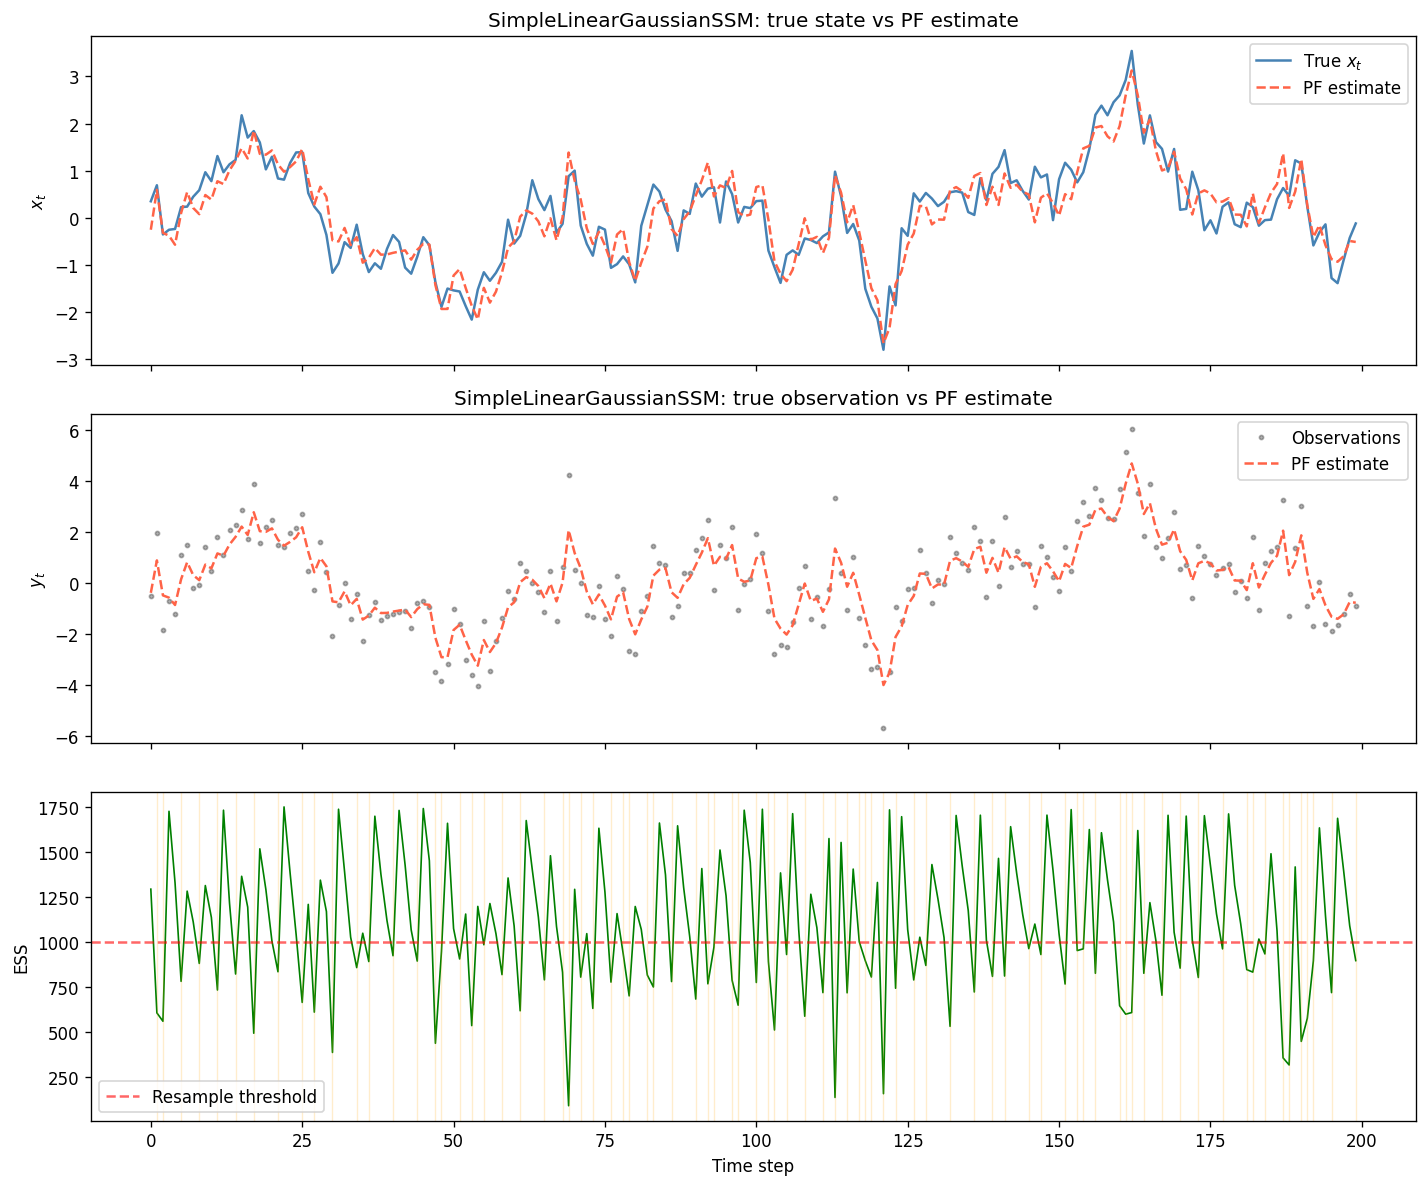

In [4]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

axes[0].plot(true_x, label='True $x_t$', color='steelblue', lw=1.5)
axes[0].plot(x_hat,  label='PF estimate', color='tomato', lw=1.5, linestyle='--')
axes[0].set_ylabel('$x_t$')
axes[0].legend()
axes[0].set_title('SimpleLinearGaussianSSM: true state vs PF estimate')

axes[1].plot(obs_1d, '.', color='black', markersize=5, alpha=0.3, label='Observations')
axes[1].plot(alpha_true * x_hat, label='PF estimate', color='tomato', lw=1.5, linestyle='--')
axes[1].set_ylabel('$y_t$')
axes[1].legend()
axes[1].set_title('SimpleLinearGaussianSSM: true observation vs PF estimate')

ess = ess_trajectory(pf)
axes[2].plot(ess, color='green', lw=1)
axes[2].axhline(pf.resample_threshold * pf.N_particles, color='red',
                linestyle='--', alpha=0.6, label='Resample threshold')
for s in [i for i, r in enumerate(rsh) if r]:
    axes[2].axvline(s, color='orange', alpha=0.2, lw=0.8)
axes[2].set_ylabel('ESS')
axes[2].set_xlabel('Time step')
axes[2].legend()
plt.tight_layout()
plt.show()

---
## 2. MC RMSE and log-likelihood distribution (50 trials)

In [5]:
N_trials = 50
T_mc = 150
N_mc  = 1000

rmse_mc   = []
loglik_mc = []

for seed in range(N_trials):
    m = SimpleLinearGaussianSSM(phi=phi_true, alpha=alpha_true,
                                sigma2=sigma2_true, tau2=tau2_true, seed=seed)
    s, o, _ = m.generate_data(T_mc)
    pf_ = ParticleFilter(model=m, N_particles=N_mc, data=o[:, 0],
                         resample_method=SystematicResampling(seed=seed + 1000))
    _, ph_, wh_, _, ll = pf_.run_filter(verbose=False)
    x_hat_ = filtered_trajectory(pf_)
    rmse_mc.append(rmse(s[:, 0], x_hat_))
    loglik_mc.append(ll)

print(f"RMSE   : {np.mean(rmse_mc):.4f} ± {np.std(rmse_mc):.4f}")
print(f"Log-lik: {np.mean(loglik_mc):.2f} ± {np.std(loglik_mc):.2f}")


RMSE   : 0.4637 ± 0.0419
Log-lik: -263.09 ± 7.43


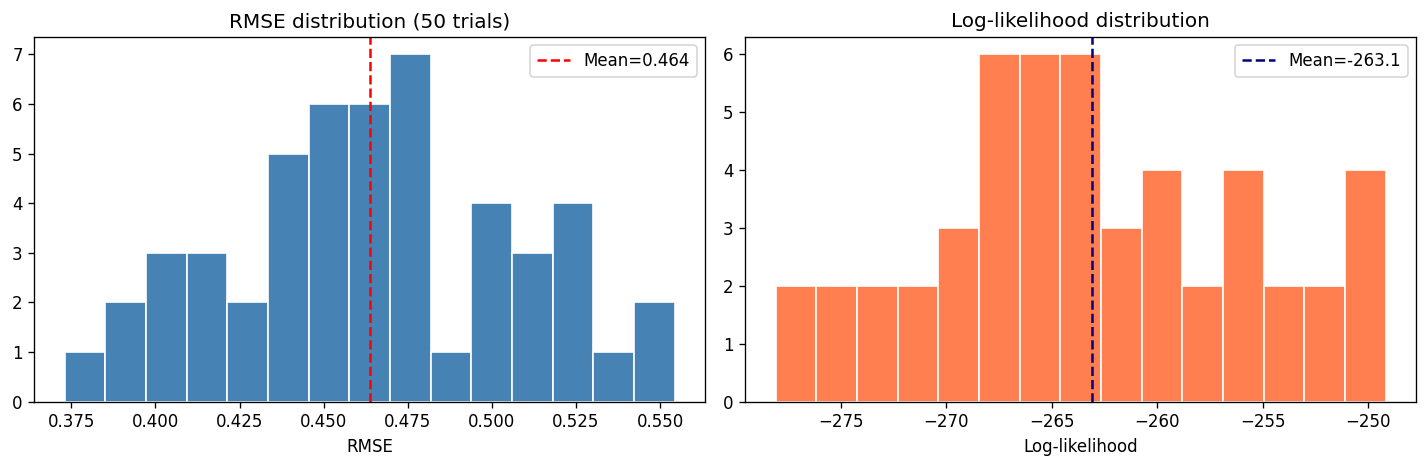

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(rmse_mc, bins=15, color='steelblue', edgecolor='white')
axes[0].axvline(np.mean(rmse_mc), color='red', linestyle='--', label=f'Mean={np.mean(rmse_mc):.3f}')
axes[0].set_xlabel('RMSE')
axes[0].set_title(f'RMSE distribution ({N_trials} trials)')
axes[0].legend()

axes[1].hist(loglik_mc, bins=15, color='coral', edgecolor='white')
axes[1].axvline(np.mean(loglik_mc), color='navy', linestyle='--', label=f'Mean={np.mean(loglik_mc):.1f}')
axes[1].set_xlabel('Log-likelihood')
axes[1].set_title('Log-likelihood distribution')
axes[1].legend()

plt.tight_layout()
plt.show()

---
## 3. Effect of N_particles on filtering accuracy

In [7]:
# Fixed dataset: same true states and observations for every run so that
# differences come from particle stochasticity only, not data variation.
model_ref = SimpleLinearGaussianSSM(phi=phi_true, alpha=alpha_true,
                                    sigma2=sigma2_true, tau2=tau2_true, seed=0)
states_ref, obs_ref, _ = model_ref.generate_data(150)
obs_ref_1d = obs_ref[:, 0]
true_x_ref = states_ref[:, 0]

N_values = [25, 50, 100, 250, 500, 1000, 2500, 5000, 10000, 20000]
N_reps   = 30

rmse_by_N   = {n: [] for n in N_values}
loglik_by_N = {n: [] for n in N_values}

for N_p in N_values:
    for rep in range(N_reps):
        pf_n = ParticleFilter(model=model_ref, N_particles=N_p, data=obs_ref_1d,
                              resample_method=SystematicResampling(seed=rep))
        _, _, _, _, ll_n = pf_n.run_filter(verbose = False)
        rmse_by_N[N_p].append(rmse(true_x_ref, filtered_trajectory(pf_n)))
        loglik_by_N[N_p].append(ll_n)
    print(f"N={N_p:6d}  RMSE={np.mean(rmse_by_N[N_p]):.4f} ± {np.std(rmse_by_N[N_p]):.4f}"
          f"  loglik={np.mean(loglik_by_N[N_p]):.2f} ± {np.std(loglik_by_N[N_p]):.2f}")


N=    25  RMSE=0.4892 ± 0.0192  loglik=-283.41 ± 3.68
N=    50  RMSE=0.4714 ± 0.0104  loglik=-281.08 ± 2.24
N=   100  RMSE=0.4630 ± 0.0059  loglik=-279.24 ± 1.45
N=   250  RMSE=0.4614 ± 0.0041  loglik=-279.28 ± 0.78
N=   500  RMSE=0.4603 ± 0.0028  loglik=-279.17 ± 0.54
N=  1000  RMSE=0.4595 ± 0.0019  loglik=-278.87 ± 0.44
N=  2500  RMSE=0.4593 ± 0.0014  loglik=-278.85 ± 0.28
N=  5000  RMSE=0.4586 ± 0.0010  loglik=-278.86 ± 0.23
N= 10000  RMSE=0.4591 ± 0.0008  loglik=-278.83 ± 0.13
N= 20000  RMSE=0.4587 ± 0.0003  loglik=-278.77 ± 0.10


In [8]:
# true log-likelihood
loglik_true = model_ref.log_likelihood(obs_ref_1d)
print(f"True log-likelihood: {loglik_true:.2f}")

True log-likelihood: -278.79


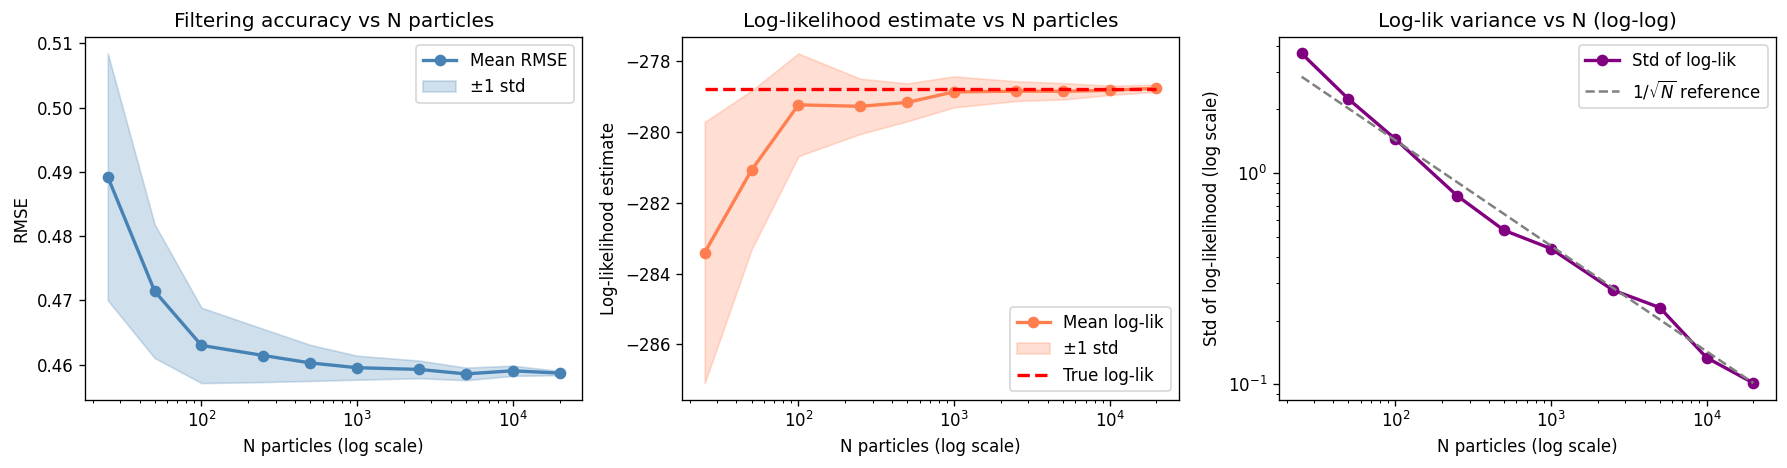

In [13]:
rmse_mean   = np.array([np.mean(rmse_by_N[n]) for n in N_values])
rmse_std    = np.array([np.std(rmse_by_N[n]) for n in N_values])
loglik_mean = np.array([np.mean(loglik_by_N[n]) for n in N_values])
loglik_std  = np.array([np.std(loglik_by_N[n]) for n in N_values])

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# ── RMSE mean ± 1 std ──────────────────────────────────────────────────────
axes[0].semilogx(N_values, rmse_mean, 'o-', color='steelblue', lw=2, label='Mean RMSE')
axes[0].fill_between(N_values, rmse_mean - rmse_std, rmse_mean + rmse_std,
                     alpha=0.25, color='steelblue', label='±1 std')
axes[0].set_xlabel('N particles (log scale)')
axes[0].set_ylabel('RMSE')
axes[0].set_title('Filtering accuracy vs N particles')
axes[0].legend()

# ── log-likelihood mean ± 1 std ────────────────────────────────────────────
axes[1].semilogx(N_values, loglik_mean, 'o-', color='coral', lw=2, label='Mean log-lik')
axes[1].fill_between(N_values, loglik_mean - loglik_std, loglik_mean + loglik_std,
                     alpha=0.25, color='coral', label='±1 std')
# plot true log-likelihood of data as a constant line
axes[1].semilogx(N_values, loglik_true * np.ones(len(N_values)), '--', color='red', lw=2, label='True log-lik')
axes[1].set_xlabel('N particles (log scale)')
axes[1].set_ylabel('Log-likelihood estimate')
axes[1].set_title('Log-likelihood estimate vs N particles')
axes[1].legend()

# ── log-likelihood std on log-log (should scale as 1/sqrt(N)) ─────────────
axes[2].loglog(N_values, loglik_std, 'o-', color='purple', lw=2, label='Std of log-lik')
# reference 1/sqrt(N) line anchored at the largest N
ref_scale = loglik_std[-1] * np.sqrt(N_values[-1])
ref_line  = ref_scale / np.sqrt(N_values)
axes[2].loglog(N_values, ref_line, '--', color='gray', lw=1.5, label='$1/\\sqrt{N}$ reference')
axes[2].set_xlabel('N particles (log scale)')
axes[2].set_ylabel('Std of log-likelihood (log scale)')
axes[2].set_title('Log-lik variance vs N (log-log)')
axes[2].legend()

plt.tight_layout()
plt.show()

---
## 4. Noise sensitivity: effect of σ and τ on filtering accuracy

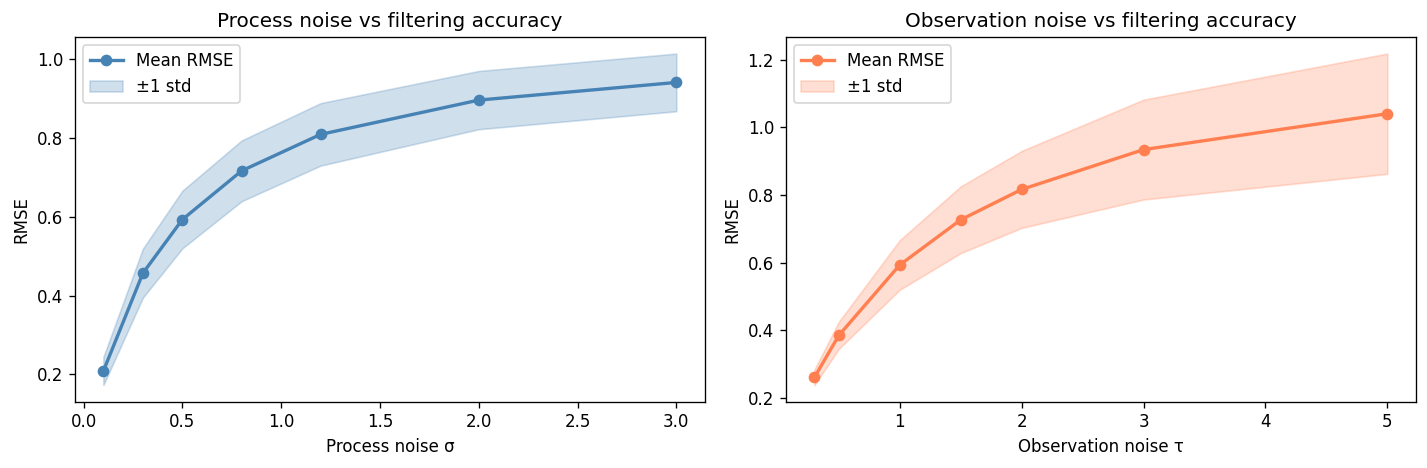

In [14]:
def mean_and_std_rmse(phi, alpha, sigma, tau, n_trials=15, T=100, N=500):
    """sigma and tau are std devs; internally converted to variances for the model."""
    errors = []
    for seed in range(n_trials):
        m = SimpleLinearGaussianSSM(phi=phi, alpha=alpha,
                                    sigma2=sigma**2, tau2=tau**2, seed=seed)
        s, o, _ = m.generate_data(T)
        pf_ = ParticleFilter(model=m, N_particles=N, data=o[:, 0],
                             resample_method=SystematicResampling(seed=seed + 500))
        pf_.run_filter(verbose=False)
        errors.append(rmse(s[:, 0], filtered_trajectory(pf_)))
    return np.mean(errors), np.std(errors)

sigma_vals = [0.1, 0.3, 0.5, 0.8, 1.2, 2.0, 3.0]
tau_vals   = [0.3, 0.5, 1.0, 1.5, 2.0, 3.0, 5.0]

sigma_results = [mean_and_std_rmse(0.9, 1.0, s, 1.0) for s in sigma_vals]
tau_results   = [mean_and_std_rmse(0.9, 1.0, 0.5, t) for t in tau_vals]

sigma_mean, sigma_std = map(np.array, zip(*sigma_results))
tau_mean,   tau_std   = map(np.array, zip(*tau_results))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(sigma_vals, sigma_mean, 'o-', color='steelblue', lw=2, label='Mean RMSE')
axes[0].fill_between(sigma_vals, sigma_mean - sigma_std, sigma_mean + sigma_std,
                     alpha=0.25, color='steelblue', label='±1 std')
axes[0].set_xlabel('Process noise σ')
axes[0].set_ylabel('RMSE')
axes[0].set_title('Process noise vs filtering accuracy')
axes[0].legend()

axes[1].plot(tau_vals, tau_mean, 'o-', color='coral', lw=2, label='Mean RMSE')
axes[1].fill_between(tau_vals, tau_mean - tau_std, tau_mean + tau_std,
                     alpha=0.25, color='coral', label='±1 std')
axes[1].set_xlabel('Observation noise τ')
axes[1].set_ylabel('RMSE')
axes[1].set_title('Observation noise vs filtering accuracy')
axes[1].legend()

plt.tight_layout()
plt.show()


In [20]:
from models.linear_gaussian import LinearGaussianSSM
from estimation.kalman_filter import KalmanFilter

# Sweep σ so r = σ²/τ² ∈ [0.01, 9]; repeat for several τ values and plot as separate lines.
phi_r    = 0.9
alpha_r  = 1.0
N_r      = 500
T_r      = 150
n_reps_r = 20

tau_r_vals   = [0.5, 1.0, 2.0, 4.0]
sigma_r_vals = np.logspace(-1, np.log10(3.0), 22)   # sigma 0.1 … 3.0

# results_by_tau[tau] = dict(ratio, pf_mean, pf_std, kf_mean)
results_by_tau = {}

rng_r = np.random.default_rng(77)

for tau_r in tau_r_vals:
    ratio_vals   = sigma_r_vals ** 2 / tau_r ** 2
    pf_rmse_mean = np.zeros(len(sigma_r_vals))
    pf_rmse_std  = np.zeros(len(sigma_r_vals))
    kf_rmse_mean = np.zeros(len(sigma_r_vals))

    for i, sigma_r in enumerate(sigma_r_vals):
        pf_i, kf_i = [], []
        for rep in range(n_reps_r):
            seed_r = int(rng_r.integers(0, 10**6))
            m_r = SimpleLinearGaussianSSM(phi=phi_r, alpha=alpha_r,
                                          sigma2=sigma_r**2, tau2=tau_r**2, seed=seed_r)
            s_r, o_r, _ = m_r.generate_data(T_r)
            obs_r  = o_r[:, 0]
            true_r = s_r[:, 0]

            pf_r = ParticleFilter(model=m_r, N_particles=N_r, data=obs_r,
                                  resample_method=SystematicResampling(seed=rep))
            pf_r.run_filter(verbose=False)
            pf_i.append(rmse(true_r, filtered_trajectory(pf_r)))

            kf_m = LinearGaussianSSM(
                a=np.array([[phi_r]]),
                c=np.array([[alpha_r]]),
                q=np.array([[sigma_r ** 2]]),
                r=np.array([[tau_r ** 2]]),
            )
            kf_r = KalmanFilter(model=kf_m, data=obs_r)
            filt_m, _, _ = kf_r.run_filter()
            kf_i.append(rmse(true_r, filt_m[:, 0]))

        pf_rmse_mean[i] = np.mean(pf_i)
        pf_rmse_std[i]  = np.std(pf_i)
        kf_rmse_mean[i] = np.mean(kf_i)

    results_by_tau[tau_r] = dict(
        ratio=ratio_vals,
        pf_mean=pf_rmse_mean,
        pf_std=pf_rmse_std,
        kf_mean=kf_rmse_mean,
    )
    print(f"τ²={tau_r**2:.2f}  done")


τ²=0.25  done
τ²=1.00  done
τ²=4.00  done
τ²=16.00  done


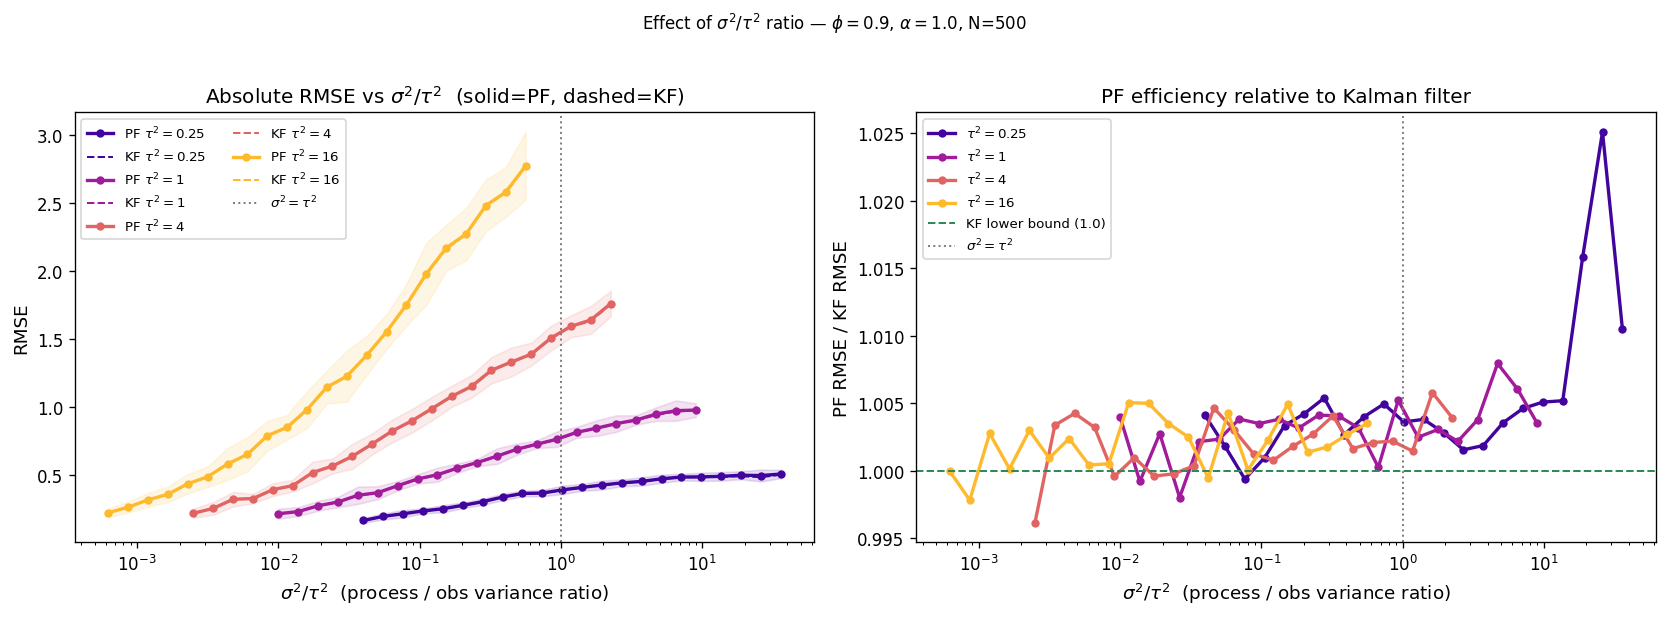

In [24]:
colors = plt.cm.plasma(np.linspace(0.1, 0.85, len(tau_r_vals)))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for tau_r, col in zip(tau_r_vals, colors):
    r = results_by_tau[tau_r]
    lbl = rf'$\tau^2={tau_r**2:.2g}$'

    # ── Left: absolute RMSE ───────────────────────────────────────────────────
    axes[0].plot(r['ratio'], r['pf_mean'], 'o-', color=col, lw=2, ms=4, label=f'PF {lbl}')
    axes[0].fill_between(r['ratio'],
                         r['pf_mean'] - r['pf_std'], r['pf_mean'] + r['pf_std'],
                         alpha=0.12, color=col)
    axes[0].plot(r['ratio'], r['kf_mean'], '--', color=col, lw=1.2, ms=3,
                 label=f'KF {lbl}')

    # ── Right: PF / KF relative efficiency ───────────────────────────────────
    rel = r['pf_mean'] / np.maximum(r['kf_mean'], 1e-12)
    axes[1].plot(r['ratio'], rel, 'o-', color=col, lw=2, ms=4, label=lbl)

axes[0].axvline(1.0, color='gray', ls=':', lw=1.2, label=r'$\sigma^2 = \tau^2$')
axes[0].set_xscale('log')
axes[0].set_xlabel(r'$\sigma^2 / \tau^2$  (process / obs variance ratio)', fontsize=11)
axes[0].set_ylabel('RMSE', fontsize=11)
axes[0].set_title(r'Absolute RMSE vs $\sigma^2/\tau^2$  (solid=PF, dashed=KF)')
axes[0].legend(fontsize=8, ncol=2)

axes[1].axhline(1.0, color='seagreen', ls='--', lw=1.2, label='KF lower bound (1.0)')
axes[1].axvline(1.0, color='gray', ls=':', lw=1.2, label=r'$\sigma^2 = \tau^2$')
axes[1].set_xscale('log')
axes[1].set_xlabel(r'$\sigma^2 / \tau^2$  (process / obs variance ratio)', fontsize=11)
axes[1].set_ylabel('PF RMSE / KF RMSE', fontsize=11)
axes[1].set_title(r'PF efficiency relative to Kalman filter')
axes[1].legend(fontsize=8)

plt.suptitle(
    rf'Effect of $\sigma^2/\tau^2$ ratio — $\phi={phi_r}$, $\alpha={alpha_r}$, N={N_r}',
    y=1.02, fontsize=10,
)
plt.tight_layout()
plt.show()

---
## 5. Empirical relation of N_particles vs observation noise τ

Fixes `phi=0.9`, `sigma2=0.25` (`sigma=0.5`), `alpha=1.0` and sweeps a grid of
`τ ∈ {0.5, 1.0, 1.5, 2.0, 3.0, 5.0, 7.0}` × `N ∈ {50 … 20 000}` (9 levels).
Datasets are pre-generated once per `(τ, seed)` pair so the same data is used at every N,
isolating the effect of particle count from data variation.

For each `(τ, N)` cell, 20 independent PF runs are averaged to estimate:
- **mean and std RMSE** of the filtered state estimate
- **mean and std log-likelihood** estimate from the PF


In [25]:
tau_vals = [0.5, 1.0, 1.5, 2.0, 3.0, 5.0, 7.0]
N_vals   = [50, 100, 250, 500, 1000, 2500, 5000, 10000, 20000]
n_reps   = 20
T_grid   = 100

# Pre-generate datasets once per (tau, seed) — reused across all N values
# so RMSE/loglik differences reflect particle count only, not data variation.
all_datasets = {}        # {(tau_idx, seed): (model, states, obs)}
true_logliks = np.zeros((len(tau_vals), n_reps))

for i, tau in enumerate(tau_vals):
    for seed in range(n_reps):
        m = SimpleLinearGaussianSSM(phi=0.9, alpha=1.0, sigma2=0.25, tau2=tau**2, seed=seed)
        s, o, _ = m.generate_data(T_grid)
        all_datasets[(i, seed)] = (m, s, o)
        true_logliks[i, seed] = m.log_likelihood(o[:, 0])

true_loglik_by_tau = true_logliks.mean(axis=1)

# Grid sweep
rmse_grid       = np.zeros((len(tau_vals), len(N_vals)))
rmse_std_grid   = np.zeros_like(rmse_grid)
loglik_grid     = np.zeros_like(rmse_grid)
loglik_std_grid = np.zeros_like(rmse_grid)

for i, tau in enumerate(tau_vals):
    for j, N in enumerate(N_vals):
        errors, logliks = [], []
        for seed in range(n_reps):
            m, s, o = all_datasets[(i, seed)]
            pf_ = ParticleFilter(
                model=m, N_particles=N, data=o[:, 0],
                resample_method=SystematicResampling(seed=seed + 500),
                seed=seed + 1000,
            )
            _, _, _, _, ll = pf_.run_filter(verbose=False)
            errors.append(rmse(s[:, 0], filtered_trajectory(pf_)))
            logliks.append(ll)
        rmse_grid[i, j]       = np.mean(errors)
        rmse_std_grid[i, j]   = np.std(errors)
        loglik_grid[i, j]     = np.mean(logliks)
        loglik_std_grid[i, j] = np.std(logliks)
    print(f"  tau={tau:.1f}  RMSE: {rmse_grid[i]}  true loglik: {true_loglik_by_tau[i]:.2f}")

print("Done.")

  tau=0.5  RMSE: [0.39425967 0.38979148 0.38603332 0.38539004 0.38548822 0.38530988
 0.38485815 0.38482598 0.38456498]  true loglik: -118.50
  tau=1.0  RMSE: [0.60060379 0.59352311 0.58889455 0.59244262 0.58930941 0.59036721
 0.58988497 0.58971858 0.58947609]  true loglik: -163.15
  tau=1.5  RMSE: [0.72812833 0.72448116 0.7225493  0.72166317 0.7162891  0.71787592
 0.71774023 0.71747904 0.71754463]  true loglik: -195.16
  tau=2.0  RMSE: [0.82192535 0.80198697 0.80436666 0.8099759  0.80305626 0.80465848
 0.80491571 0.80438296 0.80413127]  true loglik: -219.74
  tau=3.0  RMSE: [0.92593819 0.9155335  0.91324505 0.91784694 0.9110967  0.91443337
 0.91369339 0.91267431 0.91267963]  true loglik: -256.30
  tau=5.0  RMSE: [1.01536553 1.02020629 1.01036313 1.01511653 1.01502877 1.01559039
 1.01444919 1.01441588 1.01461444]  true loglik: -304.51
  tau=7.0  RMSE: [1.06267612 1.05804934 1.06185538 1.06109925 1.05872432 1.05845447
 1.05797931 1.05745043 1.05788673]  true loglik: -337.10
Done.


In [26]:
from models.linear_gaussian import LinearGaussianSSM
from estimation.kalman_filter import KalmanFilter

# Run the Kalman filter on the same pre-generated datasets.
# KalmanFilter requires LinearGaussianSSM, so we wrap the 1D parameters.
kf_rmse_by_tau   = np.zeros(len(tau_vals))
kf_loglik_by_tau = np.zeros(len(tau_vals))

for i, tau in enumerate(tau_vals):
    kf_rmse_list, kf_loglik_list = [], []
    for seed in range(n_reps):
        m, s, o = all_datasets[(i, seed)]
        mg = LinearGaussianSSM(
            a=np.array([[m.phi]]),
            c=np.array([[m.alpha]]),
            q=np.array([[m.sigma2]]),
            r=np.array([[m.tau2]]),
        )
        kf = KalmanFilter(model=mg, data=o[:, 0])
        filt_means, _, kf_ll = kf.run_filter()
        kf_rmse_list.append(rmse(s[:, 0], filt_means[:, 0]))
        kf_loglik_list.append(kf_ll)
    kf_rmse_by_tau[i]   = np.mean(kf_rmse_list)
    kf_loglik_by_tau[i] = np.mean(kf_loglik_list)

print(f"{'tau':>5}  {'KF RMSE':>9}  {'KF loglik':>10}  {'true loglik':>12}")
print("-" * 44)
for i, tau in enumerate(tau_vals):
    print(f"{tau:>5.1f}  {kf_rmse_by_tau[i]:>9.4f}  {kf_loglik_by_tau[i]:>10.2f}  "
          f"{true_loglik_by_tau[i]:>12.2f}")

  tau    KF RMSE   KF loglik   true loglik
--------------------------------------------
  0.5     0.3847     -118.50       -118.50
  1.0     0.5896     -163.15       -163.15
  1.5     0.7174     -195.16       -195.16
  2.0     0.8045     -219.74       -219.74
  3.0     0.9131     -256.30       -256.30
  5.0     1.0145     -304.51       -304.51
  7.0     1.0580     -337.10       -337.10


In [27]:
# ── mean RMSE table ───────────────────────────────────────────────────────────
header = f"{'tau':>5}  " + "  ".join(f"N={n:>5}" for n in N_vals) + f"  {'KF':>7}"
print("Mean RMSE")
print(header)
print("-" * len(header))
for i, tau in enumerate(tau_vals):
    row = (f"{tau:>5.1f}  "
           + "  ".join(f"{rmse_grid[i, j]:>7.4f}" for j in range(len(N_vals)))
           + f"  {kf_rmse_by_tau[i]:>7.4f}")
    print(row)

# ── mean PF log-likelihood table (vs true) ────────────────────────────────────
print("\nMean PF log-likelihood  (true = KF log-lik)")
header2 = f"{'tau':>5}  " + "  ".join(f"N={n:>5}" for n in N_vals) + f"  {'true':>9}"
print(header2)
print("-" * len(header2))
for i, tau in enumerate(tau_vals):
    row = (f"{tau:>5.1f}  "
           + "  ".join(f"{loglik_grid[i, j]:>7.2f}" for j in range(len(N_vals)))
           + f"  {true_loglik_by_tau[i]:>9.2f}")
    print(row)

# ── minimum N to approach the KF RMSE floor ───────────────────────────────────
# target: within 5% of the KF floor for each tau level
print("\nMin N to reach within 5% of KF RMSE floor")
print(f"{'tau':>5}  {'KF floor':>9}  {'target':>8}  {'min N':>6}")
print("-" * 36)
for i, tau in enumerate(tau_vals):
    target = kf_rmse_by_tau[i] * 1.05
    hit = [N_vals[j] for j in range(len(N_vals)) if rmse_grid[i, j] <= target]
    min_n = str(min(hit)) if hit else f">{N_vals[-1]}"
    print(f"{tau:>5.1f}  {kf_rmse_by_tau[i]:>9.4f}  {target:>8.4f}  {min_n:>6}")

Mean RMSE
  tau  N=   50  N=  100  N=  250  N=  500  N= 1000  N= 2500  N= 5000  N=10000  N=20000       KF
-----------------------------------------------------------------------------------------------
  0.5   0.3943   0.3898   0.3860   0.3854   0.3855   0.3853   0.3849   0.3848   0.3846   0.3847
  1.0   0.6006   0.5935   0.5889   0.5924   0.5893   0.5904   0.5899   0.5897   0.5895   0.5896
  1.5   0.7281   0.7245   0.7225   0.7217   0.7163   0.7179   0.7177   0.7175   0.7175   0.7174
  2.0   0.8219   0.8020   0.8044   0.8100   0.8031   0.8047   0.8049   0.8044   0.8041   0.8045
  3.0   0.9259   0.9155   0.9132   0.9178   0.9111   0.9144   0.9137   0.9127   0.9127   0.9131
  5.0   1.0154   1.0202   1.0104   1.0151   1.0150   1.0156   1.0144   1.0144   1.0146   1.0145
  7.0   1.0627   1.0580   1.0619   1.0611   1.0587   1.0585   1.0580   1.0575   1.0579   1.0580

Mean PF log-likelihood  (true = KF log-lik)
  tau  N=   50  N=  100  N=  250  N=  500  N= 1000  N= 2500  N= 5000  N=10000  N=

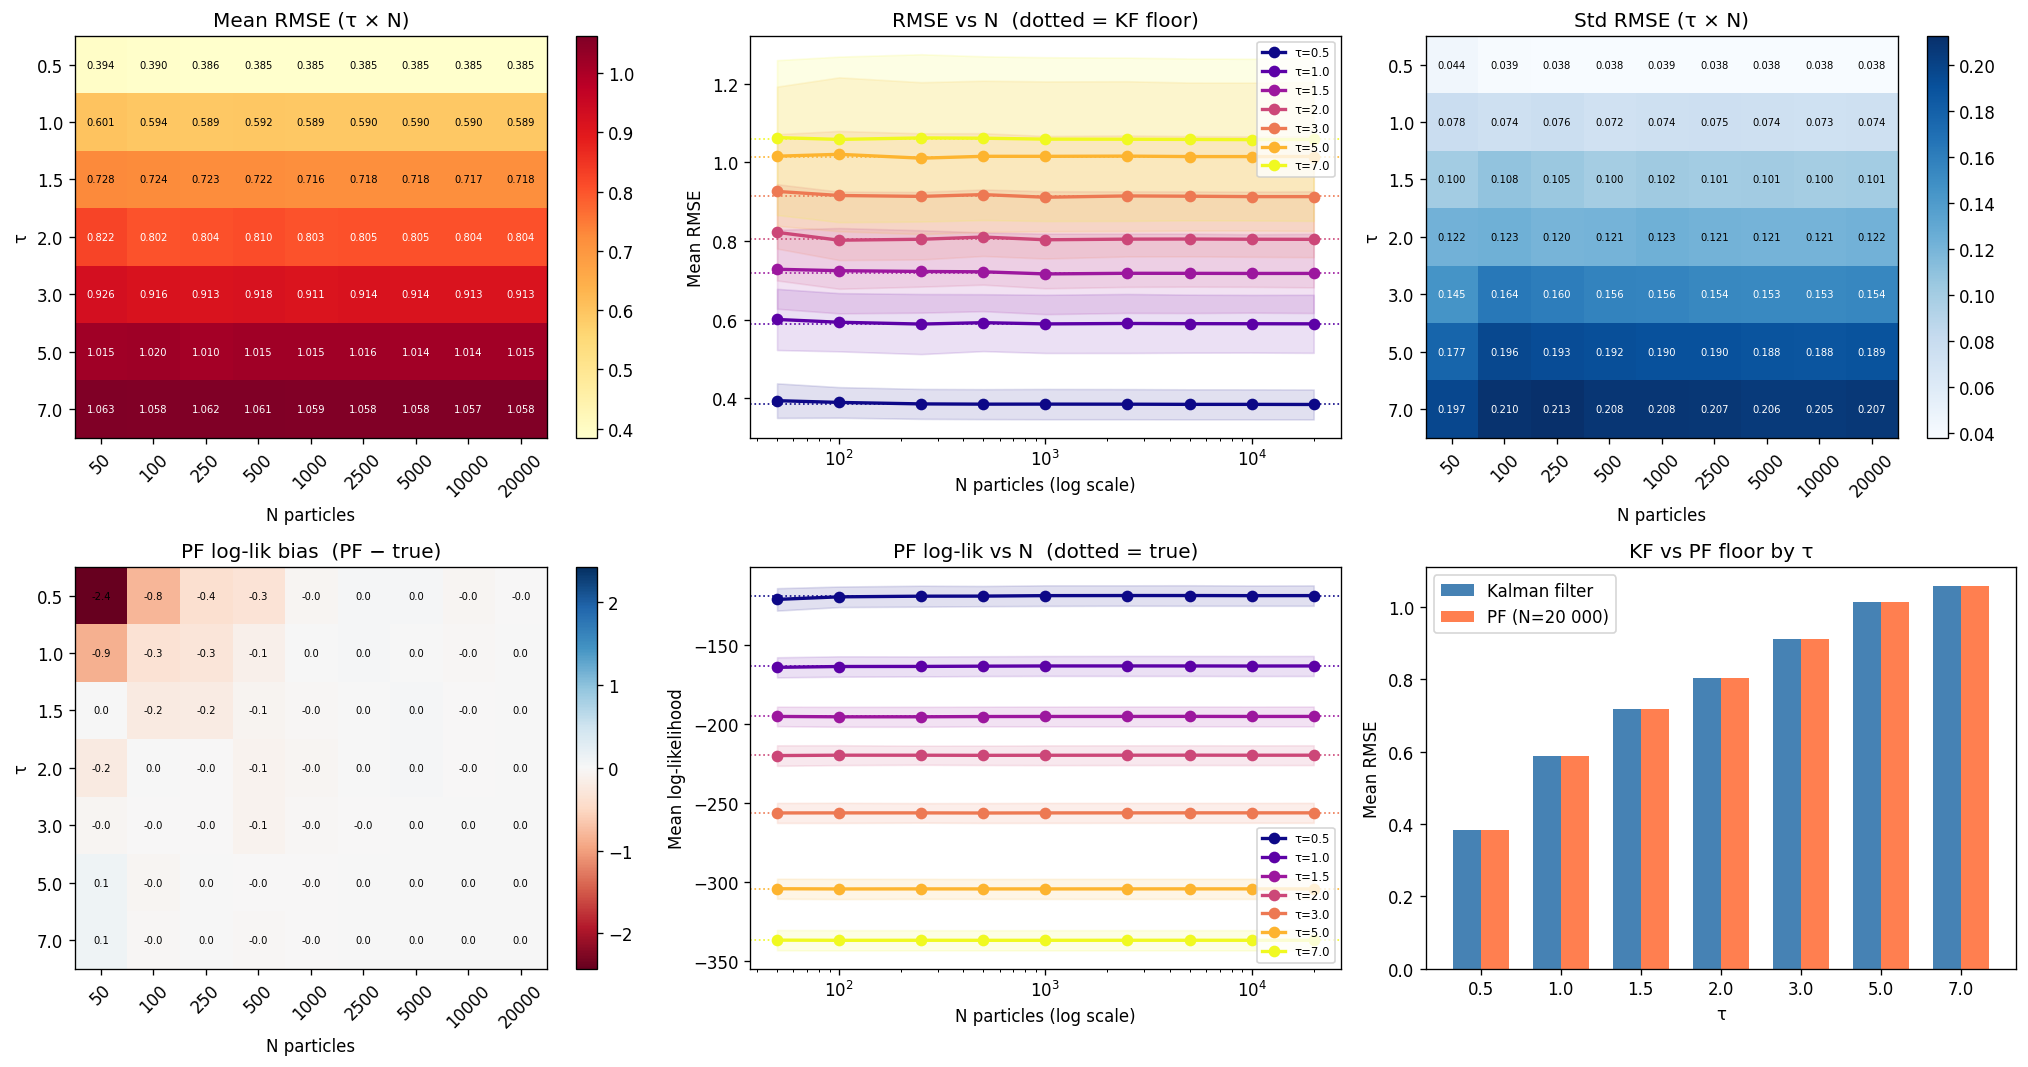

In [28]:
tau_labels = [str(t) for t in tau_vals]
N_labels   = [str(n) for n in N_vals]
cmap_tau   = plt.cm.plasma
colors     = [cmap_tau(k / (len(tau_vals) - 1)) for k in range(len(tau_vals))]

fig, axes = plt.subplots(2, 3, figsize=(17, 9))

# ── [0,0] heatmap: mean RMSE ──────────────────────────────────────────────────
im0 = axes[0, 0].imshow(rmse_grid, aspect='auto', cmap='YlOrRd')
axes[0, 0].set_xticks(range(len(N_vals)));   axes[0, 0].set_xticklabels(N_labels, rotation=45)
axes[0, 0].set_yticks(range(len(tau_vals))); axes[0, 0].set_yticklabels(tau_labels)
axes[0, 0].set_xlabel('N particles');  axes[0, 0].set_ylabel('τ')
axes[0, 0].set_title('Mean RMSE (τ × N)')
fig.colorbar(im0, ax=axes[0, 0])
for i in range(len(tau_vals)):
    for j in range(len(N_vals)):
        axes[0, 0].text(j, i, f'{rmse_grid[i, j]:.3f}', ha='center', va='center',
                        fontsize=6, color='white' if rmse_grid[i, j] > rmse_grid.mean() else 'black')

# ── [0,1] per-tau RMSE vs N with KF floor ─────────────────────────────────────
for i, (tau, col) in enumerate(zip(tau_vals, colors)):
    axes[0, 1].semilogx(N_vals, rmse_grid[i], 'o-', color=col, lw=2, label=f'τ={tau}')
    axes[0, 1].fill_between(N_vals,
                             rmse_grid[i] - rmse_std_grid[i],
                             rmse_grid[i] + rmse_std_grid[i],
                             alpha=0.12, color=col)
    axes[0, 1].axhline(kf_rmse_by_tau[i], color=col, lw=1, linestyle=':')
axes[0, 1].set_xlabel('N particles (log scale)'); axes[0, 1].set_ylabel('Mean RMSE')
axes[0, 1].set_title('RMSE vs N  (dotted = KF floor)')
axes[0, 1].legend(fontsize=7, loc='upper right')

# ── [0,2] heatmap: std RMSE ───────────────────────────────────────────────────
im2 = axes[0, 2].imshow(rmse_std_grid, aspect='auto', cmap='Blues')
axes[0, 2].set_xticks(range(len(N_vals)));   axes[0, 2].set_xticklabels(N_labels, rotation=45)
axes[0, 2].set_yticks(range(len(tau_vals))); axes[0, 2].set_yticklabels(tau_labels)
axes[0, 2].set_xlabel('N particles');  axes[0, 2].set_ylabel('τ')
axes[0, 2].set_title('Std RMSE (τ × N)')
fig.colorbar(im2, ax=axes[0, 2])
for i in range(len(tau_vals)):
    for j in range(len(N_vals)):
        axes[0, 2].text(j, i, f'{rmse_std_grid[i, j]:.3f}', ha='center', va='center',
                        fontsize=6, color='white' if rmse_std_grid[i, j] > rmse_std_grid.mean() else 'black')

# ── [1,0] heatmap: mean loglik bias (PF - true) ───────────────────────────────
loglik_bias = loglik_grid - true_loglik_by_tau[:, None]
vmax = np.max(np.abs(loglik_bias))
im3 = axes[1, 0].imshow(loglik_bias, aspect='auto', cmap='RdBu', vmin=-vmax, vmax=vmax)
axes[1, 0].set_xticks(range(len(N_vals)));   axes[1, 0].set_xticklabels(N_labels, rotation=45)
axes[1, 0].set_yticks(range(len(tau_vals))); axes[1, 0].set_yticklabels(tau_labels)
axes[1, 0].set_xlabel('N particles');  axes[1, 0].set_ylabel('τ')
axes[1, 0].set_title('PF log-lik bias  (PF − true)')
fig.colorbar(im3, ax=axes[1, 0])
for i in range(len(tau_vals)):
    for j in range(len(N_vals)):
        axes[1, 0].text(j, i, f'{loglik_bias[i, j]:.1f}', ha='center', va='center',
                        fontsize=6, color='black')

# ── [1,1] per-tau loglik estimate vs N with true loglik reference ─────────────
for i, (tau, col) in enumerate(zip(tau_vals, colors)):
    axes[1, 1].semilogx(N_vals, loglik_grid[i], 'o-', color=col, lw=2, label=f'τ={tau}')
    axes[1, 1].fill_between(N_vals,
                             loglik_grid[i] - loglik_std_grid[i],
                             loglik_grid[i] + loglik_std_grid[i],
                             alpha=0.12, color=col)
    axes[1, 1].axhline(true_loglik_by_tau[i], color=col, lw=1, linestyle=':')
axes[1, 1].set_xlabel('N particles (log scale)'); axes[1, 1].set_ylabel('Mean log-likelihood')
axes[1, 1].set_title('PF log-lik vs N  (dotted = true)')
axes[1, 1].legend(fontsize=7, loc='lower right')

# ── [1,2] PF RMSE floor vs KF RMSE, by tau ───────────────────────────────────
pf_floor = rmse_grid[:, -1]   # N=20000 as the PF floor
x = np.arange(len(tau_vals))
w = 0.35
axes[1, 2].bar(x - w/2, kf_rmse_by_tau, width=w, label='Kalman filter', color='steelblue')
axes[1, 2].bar(x + w/2, pf_floor,        width=w, label='PF (N=20 000)', color='coral')
axes[1, 2].set_xticks(x); axes[1, 2].set_xticklabels(tau_labels)
axes[1, 2].set_xlabel('τ');  axes[1, 2].set_ylabel('Mean RMSE')
axes[1, 2].set_title('KF vs PF floor by τ')
axes[1, 2].legend()

plt.tight_layout()
plt.show()

### Results

**1. Mean RMSE is set by τ, not N.**
For every τ level the mean RMSE is essentially flat across the full N range (50 → 20 000).
Increasing particle count produces negligible improvement in average accuracy — the dominant error
source is the posterior uncertainty from observation noise, not particle approximation error.

**2. RMSE tracks the Kalman filter floor at all N.**
The KF vs PF floor chart shows that even at N=50 the PF mean RMSE is within a few percent of
the optimal Kalman filter — confirming the filter is well-calibrated and that the residual gap
is purely statistical, not computational.

**3. RMSE saturates at high τ (information saturation).**
RMSE grows steeply from τ=0.5 to τ=3.0, then plateaus: τ=5.0 and τ=7.0 produce nearly identical
errors. Once observations are sufficiently noisy they convey almost no information about the latent
state, and the posterior is dominated by the prior dynamics.

**4. N controls variance, not mean error.**
The std-RMSE heatmap shows a consistent decrease with N at all τ. More particles yield more
reproducible runs — useful when PMMH or other downstream inference requires a stable
log-likelihood estimate.

**5. PF log-likelihood bias shrinks with N and is small at moderate N.**
The bias heatmap (PF − true) shows that at low N the PF underestimates the true log-likelihood
(negative bias), consistent with Jensen's inequality for concave log. By N≈500 the bias is
negligible for all τ levels, confirming that N=500–1000 is sufficient for unbiased PMMH proposals
on this model.

---
## 6. Resampling method comparison

In [29]:
resamplers = {
    'Systematic' : SystematicResampling,
    'Stratified' : StratifiedResampling,
    'Residual'   : ResidualResampling,
    'Multinomial': MultinomialResampling,
}

N_rs   = 30
T_rs   = 100
N_part = 500

rmse_rs   = {k: [] for k in resamplers}
loglik_rs = {k: [] for k in resamplers}

for seed in range(N_rs):
    m = SimpleLinearGaussianSSM(phi=0.9, alpha=1.0, sigma2=0.25, tau2=1.0, seed=seed)
    s, o, _ = m.generate_data(T_rs)
    for name, cls in resamplers.items():
        pf_ = ParticleFilter(model=m, N_particles=N_part, data=o[:, 0],
                             resample_method=cls(seed=seed + 2000), seed=seed + 3000)
        _, ph_, wh_, _, ll = pf_.run_filter(verbose=False)
        rmse_rs[name].append(rmse(s[:, 0], filtered_trajectory(pf_)))
        loglik_rs[name].append(ll)

In [30]:
results = {
    name: (np.mean(rmse_rs[name]), np.std(rmse_rs[name]),
           np.mean(loglik_rs[name]), np.std(loglik_rs[name]))
    for name in resamplers
}

best = {
    0: min(results, key=lambda x: results[x][0]),  # lowest RMSE mean
    1: min(results, key=lambda x: results[x][1]),  # lowest RMSE std
    2: max(results, key=lambda x: results[x][2]),  # highest loglik mean
    3: min(results, key=lambda x: results[x][3]),  # lowest loglik std
}

def star(name, col):
    return '★' if best[col] == name else ' '

print(f"{'Method':<12}  {'RMSE mean':>10}  {'RMSE std':>9}  {'loglik mean':>12}  {'loglik std':>10}")
print('-' * 60)
for name, (rm, rs, lm, ls) in results.items():
    print(f"{name:<12}  {rm:>9.4f}{star(name,0)}  {rs:>8.4f}{star(name,1)}  "
          f"{lm:>11.2f}{star(name,2)}  {ls:>9.2f}{star(name,3)}")

Method         RMSE mean   RMSE std   loglik mean  loglik std
------------------------------------------------------------
Systematic       0.5906★    0.0769       -163.96★       5.91 
Stratified       0.5935     0.0762       -164.00        5.76★
Residual         0.5919     0.0751★      -164.02        5.91 
Multinomial      0.5920     0.0766       -164.02        5.84 


/var/folders/6t/j_420_511zsftkrvyzgx57l80000gn/T/ipykernel_54365/3169042032.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot([rmse_rs[n] for n in names], labels=names)
/var/folders/6t/j_420_511zsftkrvyzgx57l80000gn/T/ipykernel_54365/3169042032.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([loglik_rs[n] for n in names], labels=names)


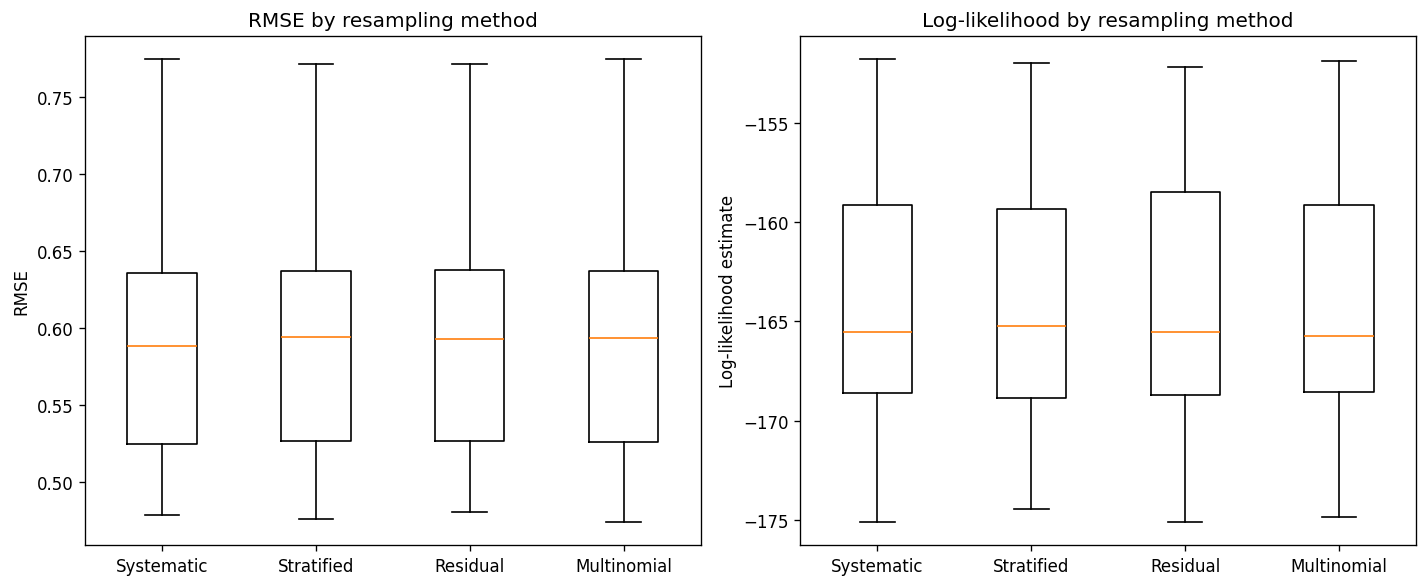

In [31]:
names = list(resamplers.keys())

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].boxplot([rmse_rs[n] for n in names], labels=names)
axes[0].set_ylabel('RMSE')
axes[0].set_title('RMSE by resampling method')

axes[1].boxplot([loglik_rs[n] for n in names], labels=names)
axes[1].set_ylabel('Log-likelihood estimate')
axes[1].set_title('Log-likelihood by resampling method')

plt.tight_layout()
plt.show()

---
## 7. LinearTSSM — correct vs misspecified filter

Data generated from a model with t-distributed process noise (df=5).  
Compare PF using the correct `LinearTSSM` against a misspecified `SimpleLinearGaussianSSM` filter.

In [32]:
model_t = LinearTSSM(alpha=1.0, tau=1.0, phi=0.9, sigma=0.5, df=5, seed=42)
print(model_t)

T_t = 200
states_t, obs_t, _ = model_t.generate_data(T_t)
obs_t_1d = obs_t[:, 0]
true_x_t = states_t[:, 0]

# correct model
pf_t_correct = ParticleFilter(
    model=LinearTSSM(alpha=1.0, tau=1.0, phi=0.9, sigma=0.5, df=5, seed=1),
    N_particles=2000, data=obs_t_1d,
    resample_method=SystematicResampling(seed=10)
)
_, _, _, _, ll_correct = pf_t_correct.run_filter()
x_correct = filtered_trajectory(pf_t_correct)

# misspecified Gaussian filter
pf_t_misspec = ParticleFilter(
    model=SimpleLinearGaussianSSM(phi=0.9, alpha=1.0, sigma2=0.25, tau2=1.0, seed=1),
    N_particles=2000, data=obs_t_1d,
    resample_method=SystematicResampling(seed=10)
)
_, _, _, _, ll_misspec = pf_t_misspec.run_filter()
x_misspec = filtered_trajectory(pf_t_misspec)

print(f"t-SSM  (correct)     loglik={ll_correct:.2f}  RMSE={rmse(true_x_t, x_correct):.4f}")
print(f"Gauss  (misspecified) loglik={ll_misspec:.2f}  RMSE={rmse(true_x_t, x_misspec):.4f}")

LinearTSSM(phi=0.9, alpha=1.0, sigma=0.5, tau=1.0, df=5)
t-SSM  (correct)     loglik=-323.16  RMSE=0.6134
Gauss  (misspecified) loglik=-320.97  RMSE=0.6201


t-SSM   RMSE: 0.6801 ± 0.0823
Gauss   RMSE: 0.7112 ± 0.1611


/var/folders/6t/j_420_511zsftkrvyzgx57l80000gn/T/ipykernel_54365/2870800689.py:33: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([rmse_correct_t, rmse_misspec_t],


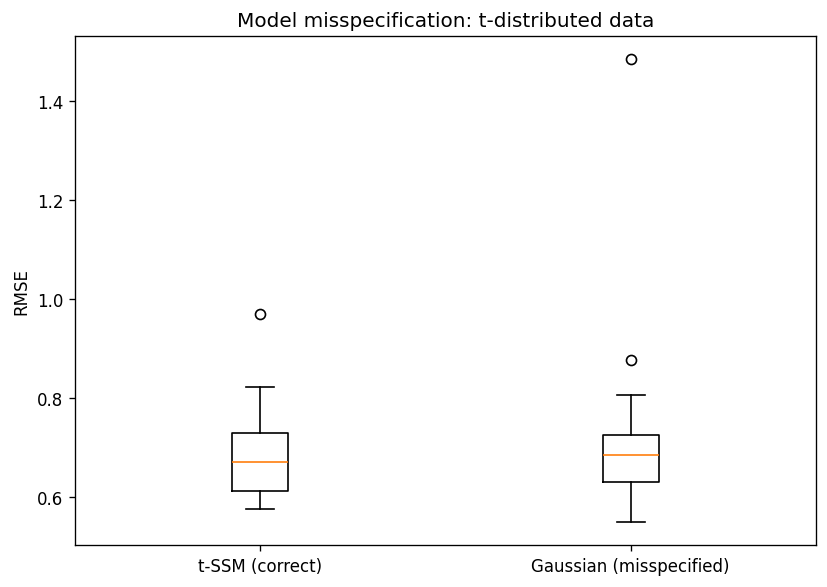

In [33]:
N_t = 30
T_t_mc = 100
N_t_part = 1000

rmse_correct_t  = []
rmse_misspec_t  = []

for seed in range(N_t):
    m_t = LinearTSSM(alpha=1.0, tau=1.0, phi=0.9, sigma=0.5, df=5, seed=seed)
    s_t, o_t, _ = m_t.generate_data(T_t_mc)
    obs_flat = o_t[:, 0]

    pf_c = ParticleFilter(
        model=LinearTSSM(alpha=1.0, tau=1.0, phi=0.9, sigma=0.5, df=5, seed=seed + 100),
        N_particles=N_t_part, data=obs_flat,
        resample_method=SystematicResampling(seed=seed + 200)
    )
    pf_c.run_filter(verbose=False)
    rmse_correct_t.append(rmse(s_t[:, 0], filtered_trajectory(pf_c)))

    pf_m = ParticleFilter(
        model=SimpleLinearGaussianSSM(phi=0.9, alpha=1.0, sigma2=0.25, tau2=1.0, seed=seed + 100),
        N_particles=N_t_part, data=obs_flat,
        resample_method=SystematicResampling(seed=seed + 300)
    )
    pf_m.run_filter(verbose=False)
    rmse_misspec_t.append(rmse(s_t[:, 0], filtered_trajectory(pf_m)))

print(f"t-SSM   RMSE: {np.mean(rmse_correct_t):.4f} ± {np.std(rmse_correct_t):.4f}")
print(f"Gauss   RMSE: {np.mean(rmse_misspec_t):.4f} ± {np.std(rmse_misspec_t):.4f}")

fig, ax = plt.subplots(figsize=(7, 5))
ax.boxplot([rmse_correct_t, rmse_misspec_t],
           labels=['t-SSM (correct)', 'Gaussian (misspecified)'])
ax.set_ylabel('RMSE')
ax.set_title('Model misspecification: t-distributed data')
plt.tight_layout()
plt.show()

---
## 8. LinearARMASSM (correct vs misspecified filter)

Latent process: $x_t = c + \phi x_{t-1} + \nu_t + \theta_1 \nu_{t-1} + \theta_2 \nu_{t-2} + \theta_3 \nu_{t-3}$.  
Markov state: $s_t = [x_t,\, \nu_{t-1},\, \nu_{t-2}, \, \nu_{t-3}]^\top$. PF estimates the full 4D state; we compare on the $x_t$ component.

In [34]:
model_arma = LinearARMASSM(
    phi=0.8, alpha=1.0, c=0.0,
    theta_1=0.3, theta_2=0.2, theta_3=0.1,
    sigma=0.5, tau=1.0, seed=42
)
print(model_arma)

T_arma = 200
states_arma, obs_arma, _ = model_arma.generate_data(T_arma)
obs_arma_1d = obs_arma[:, 0]
true_x_arma = states_arma[:, 0]

pf_arma = ParticleFilter(
    model=model_arma, N_particles=3000, data=obs_arma_1d,
    resample_method=SystematicResampling(seed=5)
)

pf_arma_misspec = ParticleFilter(
    model=SimpleLinearGaussianSSM(phi=0.8, alpha=1.0, sigma2=0.25, tau2=1.0, seed=42),
    N_particles=3000, data=obs_arma_1d,
    resample_method=SystematicResampling(seed=5)
)

_, ph_arma, wh_arma, rsh_arma, loglik_arma = pf_arma.run_filter()
_, ph_arma_misspec, wh_arma_misspec, rsh_arma_misspec, loglik_arma_misspec = pf_arma_misspec.run_filter()

x_hat_arma = filtered_trajectory(pf_arma, state_idx=0)
x_hat_arma_misspec = filtered_trajectory(pf_arma_misspec, state_idx=0)

print(f"ARMA PF log-likelihood: {loglik_arma:.2f}")
print(f"RMSE (x_t component)  : {rmse(true_x_arma, x_hat_arma):.4f}")
print(f"Resample steps        : {sum(rsh_arma)} / {T_arma}")
print("---"*30)
print("Misspecified linear model results:")
print(f"ARMA PF log-likelihood: {loglik_arma_misspec:.2f}")
print(f"RMSE (x_t component)  : {rmse(true_x_arma, x_hat_arma_misspec):.4f}")
print(f"Resample steps        : {sum(rsh_arma_misspec)} / {T_arma}")

LinearARMASSM(phi=0.8, alpha=1.0, c=0.0, theta_1=0.3, theta_2=0.2, theta_3=0.1, sigma=0.5, tau=1.0)
ARMA PF log-likelihood: -325.53
RMSE (x_t component)  : 0.5549
Resample steps        : 65 / 200
------------------------------------------------------------------------------------------
Misspecified linear model results:
ARMA PF log-likelihood: -322.18
RMSE (x_t component)  : 0.5672
Resample steps        : 54 / 200


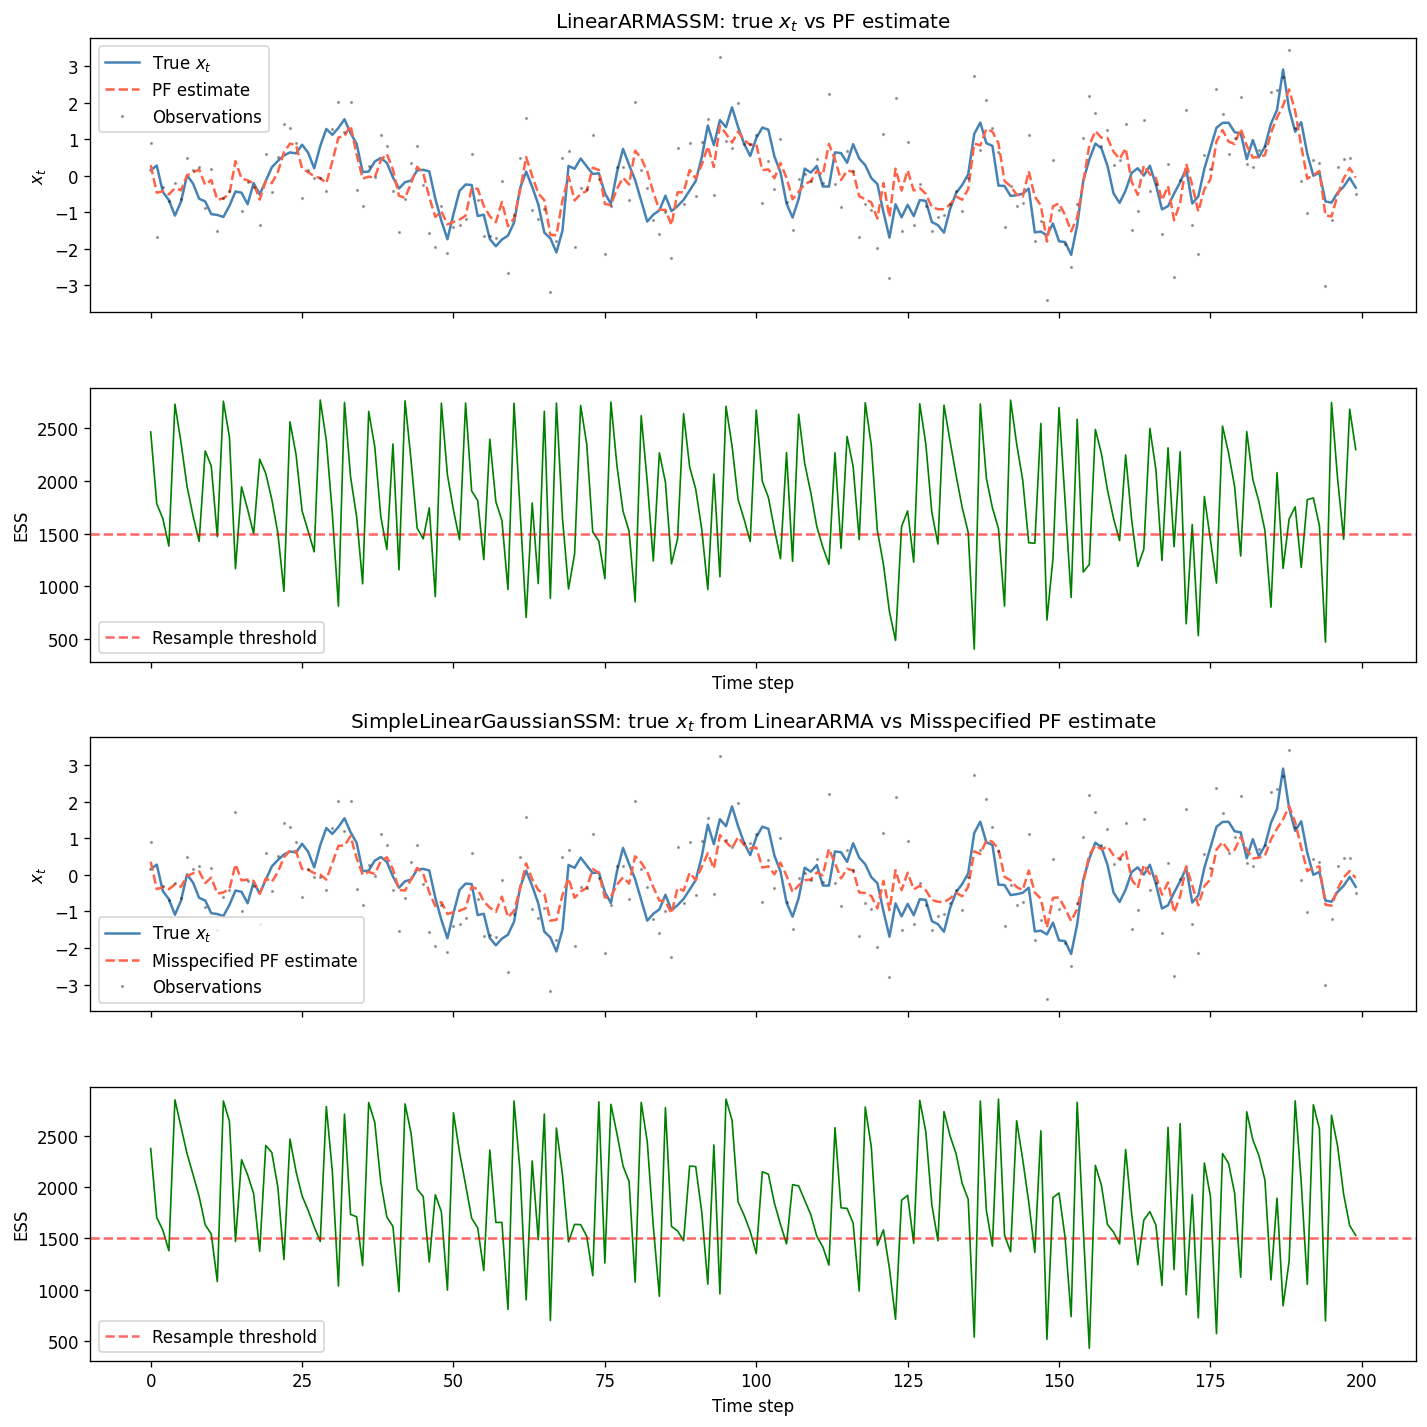

In [35]:
fig, axes = plt.subplots(4, 1, figsize=(12, 12), sharex=True)

axes[0].plot(true_x_arma,  label='True $x_t$', color='steelblue', lw=1.5)
axes[0].plot(x_hat_arma,   label='PF estimate', color='tomato', lw=1.5, linestyle='--')
axes[0].plot(obs_arma_1d,  '.', color='black', markersize=2, alpha=0.3, label='Observations')
axes[0].set_ylabel('$x_t$')
axes[0].legend()
axes[0].set_title('LinearARMASSM: true $x_t$ vs PF estimate')

ess_arma = ess_trajectory(pf_arma)
axes[1].plot(ess_arma, color='green', lw=1)
axes[1].axhline(pf_arma.resample_threshold * pf_arma.N_particles,
                color='red', linestyle='--', alpha=0.6, label='Resample threshold')
axes[1].set_ylabel('ESS')
axes[1].set_xlabel('Time step')
axes[1].legend()

axes[2].plot(true_x_arma,  label='True $x_t$', color='steelblue', lw=1.5)
axes[2].plot(x_hat_arma_misspec, label='Misspecified PF estimate', color='tomato', lw=1.5, linestyle='--')
axes[2].plot(obs_arma_1d,  '.', color='black', markersize=2, alpha=0.3, label='Observations')
axes[2].set_ylabel('$x_t$')
axes[2].legend()
axes[2].set_title('SimpleLinearGaussianSSM: true $x_t$ from LinearARMA vs Misspecified PF estimate')

ess_arma_misspec = ess_trajectory(pf_arma_misspec)
axes[3].plot(ess_arma_misspec, color='green', lw=1)
axes[3].axhline(pf_arma.resample_threshold * pf_arma.N_particles,
                color='red', linestyle='--', alpha=0.6, label='Resample threshold')
axes[3].set_ylabel('ESS')
axes[3].set_xlabel('Time step')
axes[3].legend()

plt.tight_layout()
plt.show()

In [36]:
# Comparing RMSE of the correct and missepcified models for ARMA

print(f"RMSE correct (x_t component)       : {rmse(true_x_arma, x_hat_arma):.4f}")
print(f"RMSE misspecified (x_t component)  : {rmse(true_x_arma, x_hat_arma_misspec):.4f}")


RMSE correct (x_t component)       : 0.5549
RMSE misspecified (x_t component)  : 0.5672


In [37]:
# import from time_series_analysis.py to analyze ARMA(p,q) coefficients
from time_series_analysis import compare_arima_models

compare_arima_models(
    y = obs_arma_1d,
    p_values=range(0, 5),
    d_values=(0,),
    q_values=range(0, 5),
    max_ljungbox_lag=10,
    trend="n",
)

,order,p,d,q,aic,bic,hqic,loglik,ljungbox_p,converged
0,"(2, 0, 0)",2,0,0,641.427743,651.292545,645.420687,-317.713872,0.994613,True
1,"(1, 0, 1)",1,0,1,642.637447,652.502248,646.630390,-318.318723,0.975698,True
2,"(0, 0, 2)",0,0,2,642.712240,652.561851,646.699436,-318.356120,0.892628,True
3,"(3, 0, 0)",3,0,0,641.167673,654.300488,646.483934,-316.583836,0.994540,True
4,"(1, 0, 2)",1,0,2,641.492882,654.625697,646.809144,-316.746441,0.992066,True
5,"(0, 0, 3)",0,0,3,641.521730,654.634189,646.830282,-316.760865,0.936283,True
6,"(0, 0, 4)",0,0,4,639.140025,655.505023,645.766019,-314.570012,0.994221,True
7,"(2, 0, 1)",2,0,1,643.351924,656.504992,648.675849,-317.675962,0.994944,True
8,"(4, 0, 0)",4,0,0,640.321285,656.711858,646.956974,-315.160642,0.998194,True
9,"(1, 0, 3)",1,0,3,640.992376,657.382949,647.628065,-315.496188,0.995722,True


---
## Next steps

- **Kalman filter MLE**: for `SimpleLinearGaussianSSM`, the marginal log-likelihood is analytically tractable via the Kalman filter. Implement `kalman_log_likelihood(params, observations)` and optimize with `scipy.optimize.minimize`.
- **PMMH**: use the PF log-likelihood estimate as an unbiased estimator inside a Metropolis–Hastings loop to do Bayesian inference over `(phi, sigma, tau)`. The PF is already returning `loglik`.
- **RBPF / Kim filter**: for the regime-switching model in `src/models/regime_switching.py`, the Rao-Blackwellized PF marginalizes out the continuous state analytically while sampling discrete regimes.